In [13]:
import numpy as np
import torch
import torch.nn as nn
from copy import deepcopy
from numpy.linalg import matrix_rank
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

In [14]:
base_layer = nn.Linear(1024, 1024, bias=False)
base_layer.weight.shape, base_layer.weight.numel()

(torch.Size([1024, 1024]), 1048576)

We’d need one million updates to apply to these one million weights. So, let’s create two small matrices:

The first one, let’s call it layer A, has to match the input features of the base layer.

The second one, let’s call it layer B, has to match the output features of the base layer.

Since they need to be multiplied, their inner ("facing") dimensions must match:
◦ This is the rank of the matrix that will result from their multiplication, and you get to choose this value.

# rank = 8

Rank of a matrix = number of linearly independent rows (or columns).

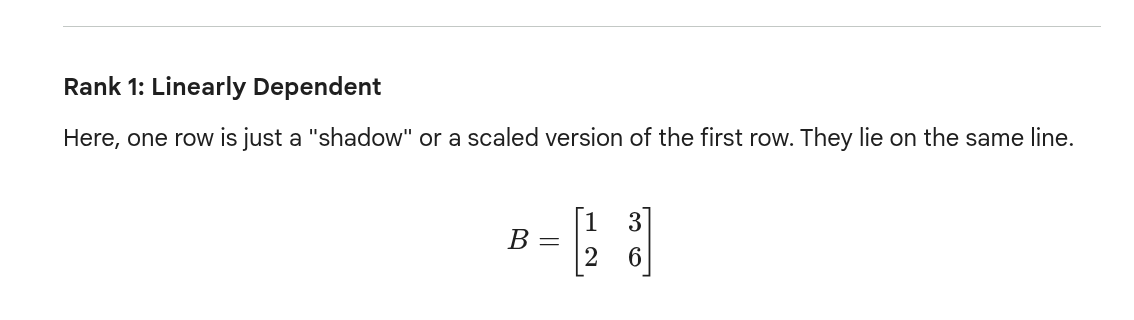

## here row  1 = 1 ,3 

## row 2  = 2,6

but row 2 = 2 * row 1 

that means row 2 is dependent on row 1 

that means row 1 is only independent row here so rank =1 

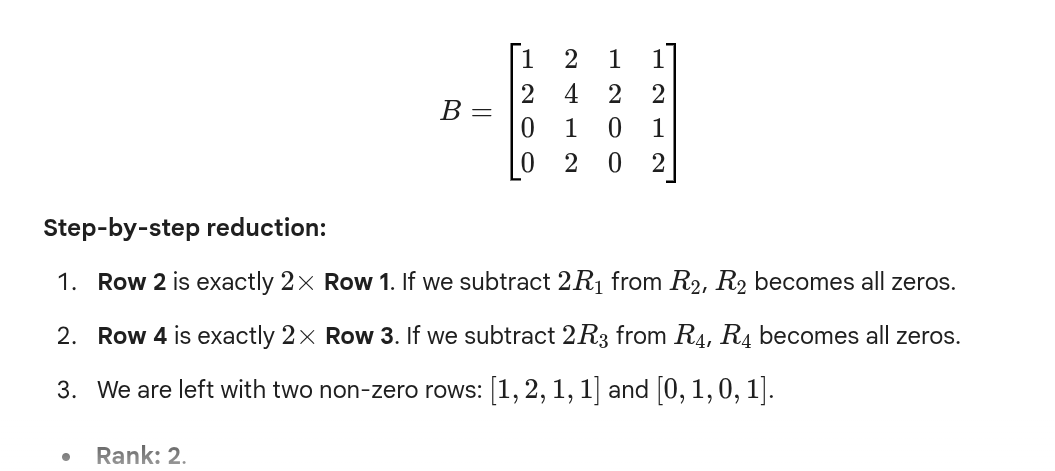

## so on 

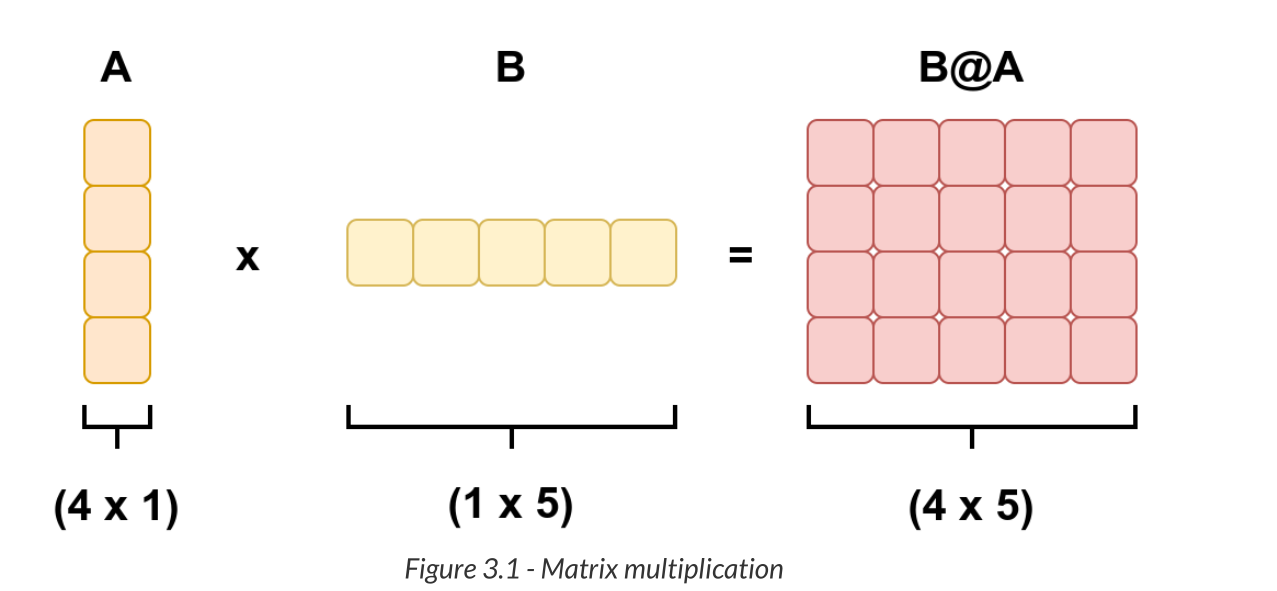

4x5 (big matrix ) if formed by , two small matrix (4X1) and 1X5   ...

this means using two small matrix we can achive lora 

## same here , most weights redendency weights (that is dependend weights are forzen ) 
## and two low rank matrix are selected 

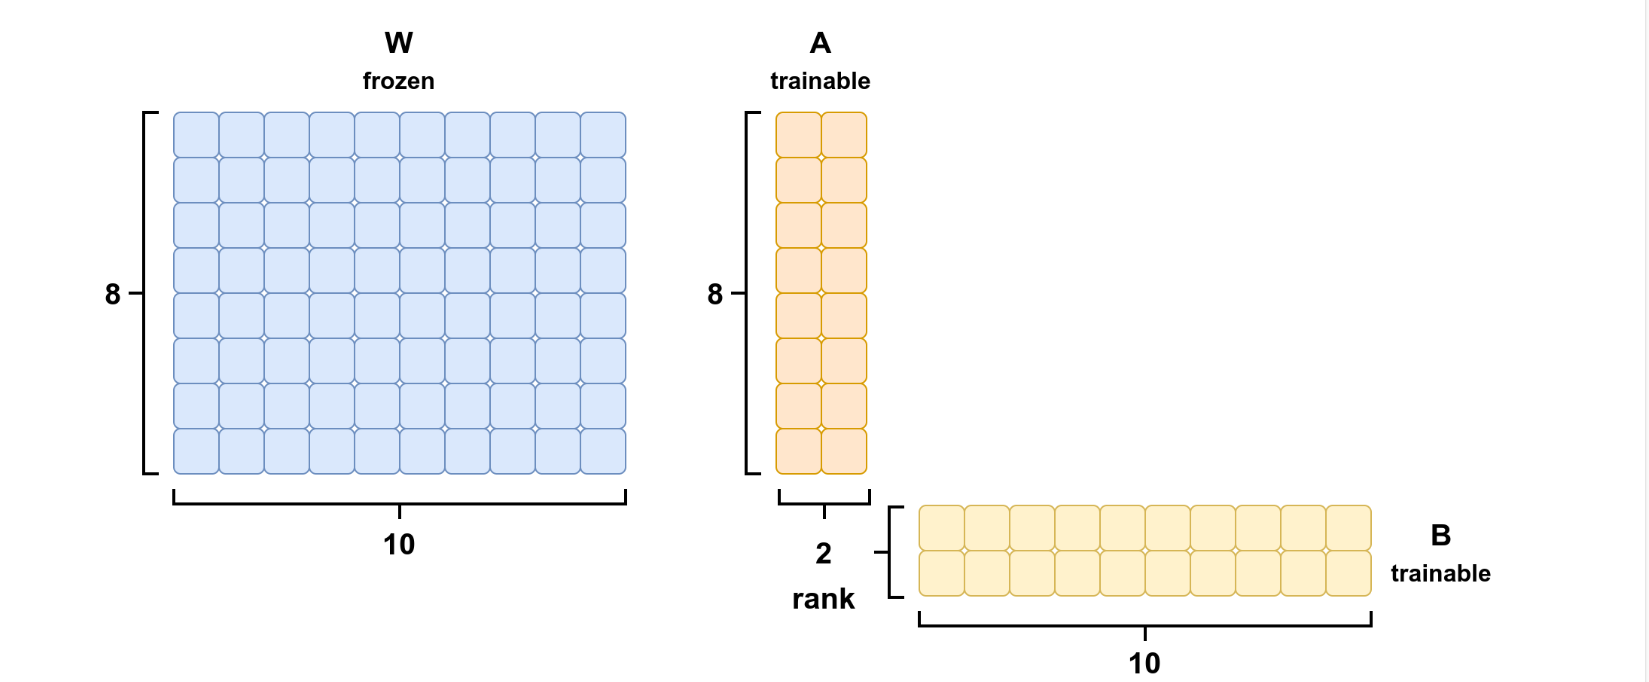

In [5]:
torch.manual_seed(11)
r = 8
layer_A = nn.Linear(base_layer.in_features, r, bias=False)
layer_B = nn.Linear(r, base_layer.out_features, bias=False)
layer_A, layer_B

(Linear(in_features=1024, out_features=8, bias=False),
 Linear(in_features=8, out_features=1024, bias=False))

In [7]:
layer_A.weight.numel(), layer_B.weight.numel()
## These two small matrices—each layer’s weights—have only 8,192 parameters each:

(8192, 8192)

## if we multiply them then we get full sized 1million parameter matrix as result

In [8]:
composite = layer_B.weight @ layer_A.weight
composite.shape , composite.numel()

(torch.Size([1024, 1024]), 1048576)

##  most are redundency , or denepend row / or coloumsn , so if we run rank we will find its true dimension 

In [10]:
matrix_rank(composite.detach().numpy())

np.int64(8)

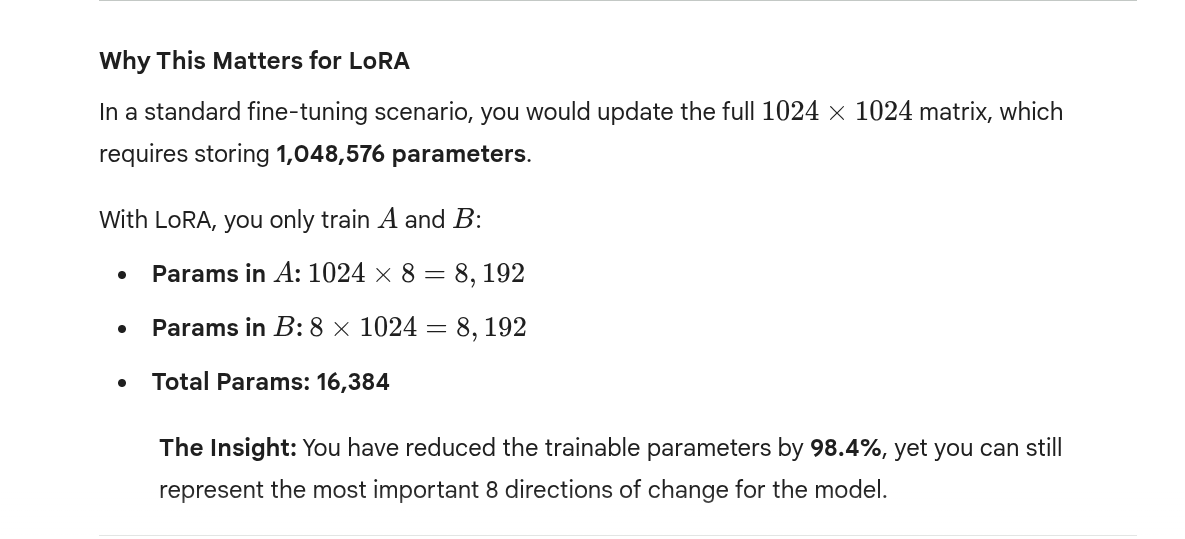

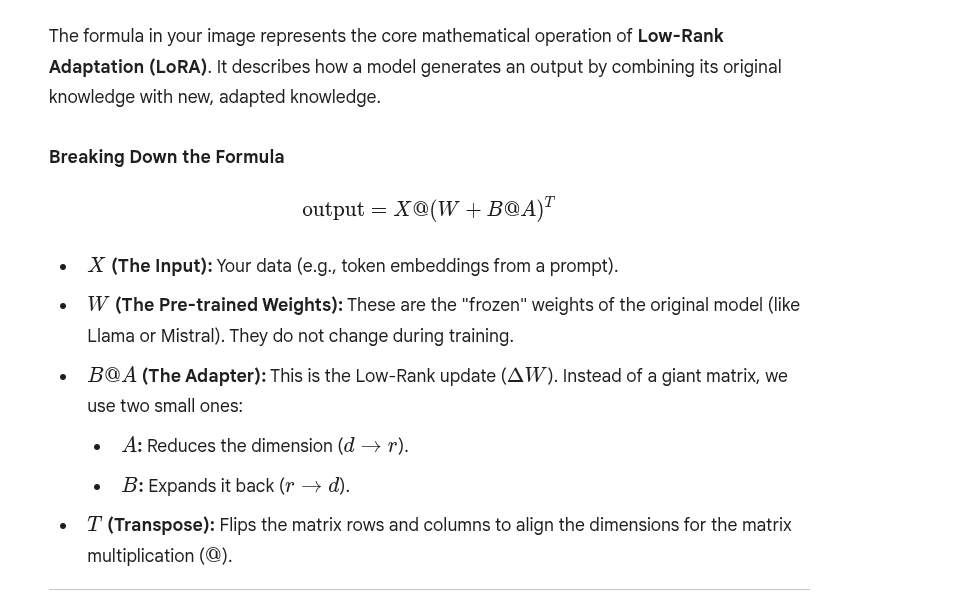

In [11]:
torch.manual_seed(19)
batch = torch.randn(1, 1024)
batch @ (base_layer.weight.data + layer_B.weight @ layer_A.weight).T

tensor([[ 1.0522, -0.1983, -0.0075,  ..., -0.4730,  0.6975,  1.0501]],
       grad_fn=<MmBackward0>)

## distributive property of matrix multiplication,

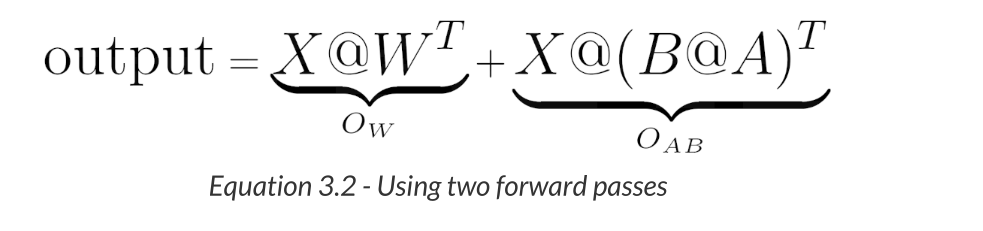

## PEFT

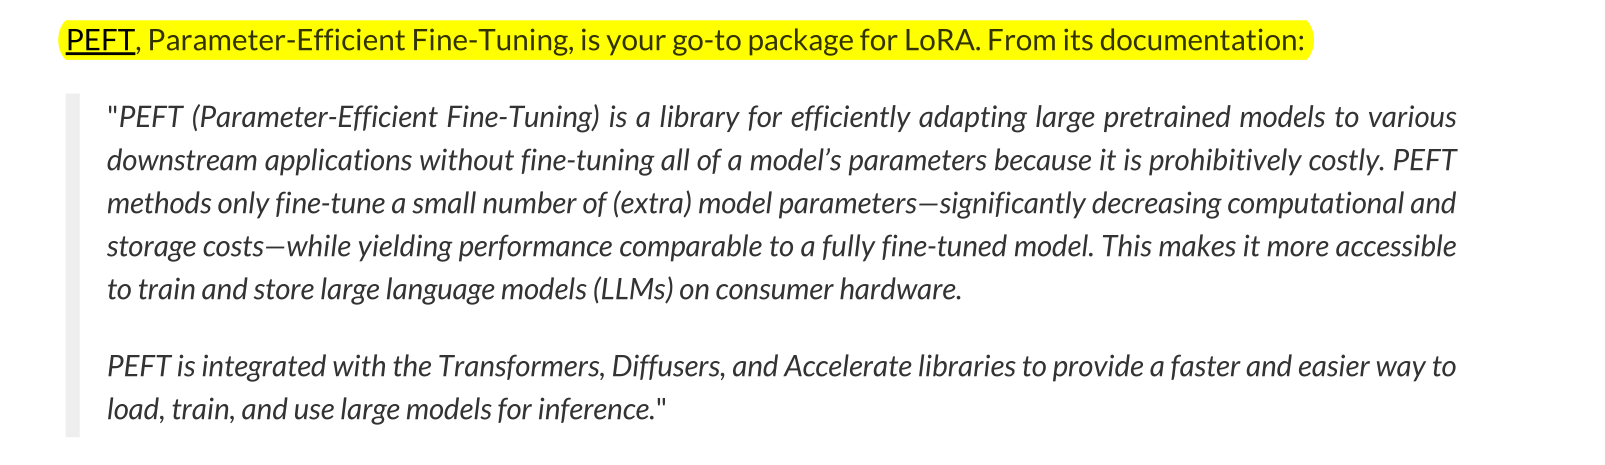

In [5]:
lora_config = LoraConfig()
lora_config

LoraConfig(task_type=None, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.18.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=8, target_modules=None, exclude_modules=None, lora_alpha=8, lora_dropout=0.0, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, arrow_config=None, ensure_weight_tying=False)

task_type arguement : since we’re handling LLMs, is always going to be "CAUSAL_LM". So, the typical—and
minimal—configuration looks like this:

In [9]:
config = LoraConfig(
                    r=8,
                    lora_alpha=16,
                    lora_dropout=0.05,
                    bias="none",
                    task_type="CAUSAL_LM", )

# How does it determine which layers should have adapters? Are only quantized layers eligible ?

Popular architectures come with preconfigured lists of target layers where the adapters will be applied.


The target layers will receive adapters whether they’re quantized or not; although quantized layers are
natural candidates because they cannot be updated. 


Yes, you can, any Linear (or Conv1D!) layer can have an adapter to call its own.



##### If the model of your choice uses Conv1D layers and you want to attach adapters to them, there is one extra
#### configuration you have to add: fan_in_fan_out: True.

##  target_modules

may be new models which is justt now publish has no preconfigured list of target layers currently instedd version of the petf library in that case it throws

ValueError: Please specify `target_modules` in `peft_config`

![Screenshot from 2026-03-12 14-09-30.png](<attachment:Screenshot from 2026-03-12 14-09-30.png>)
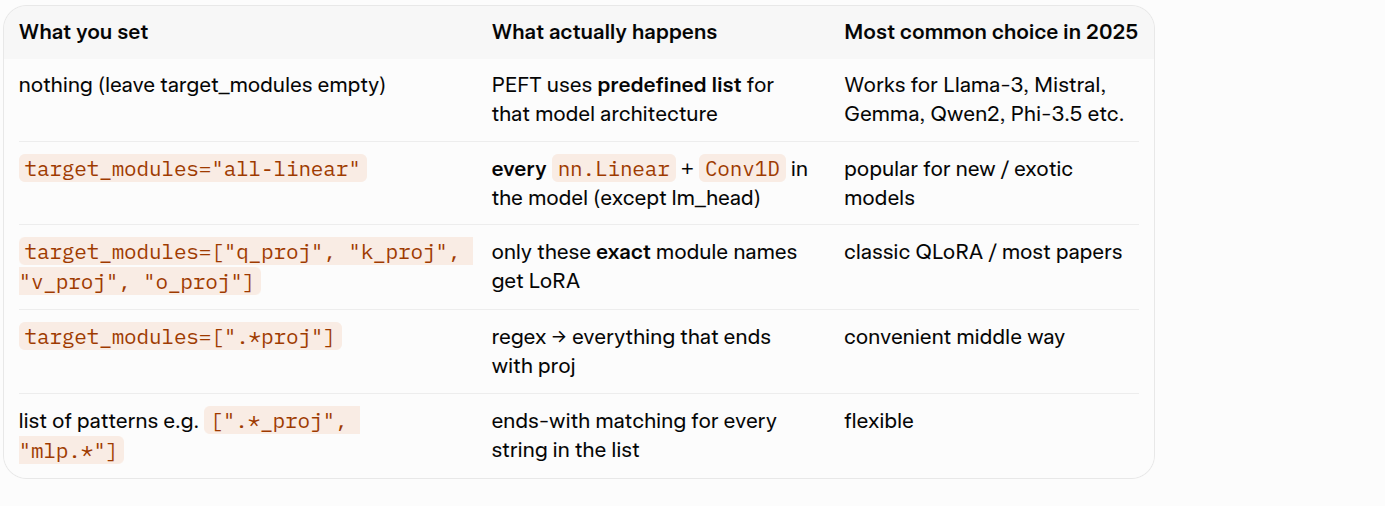

In [18]:
import torch
from transformers import AutoModelForCausalLM

# 1️⃣ Check if native bf16 is supported on this GPU
supported = torch.cuda.is_bf16_supported(including_emulation=False)

# 2️⃣ Decide compute dtype: bf16 if supported, else float32
compute_dtype = torch.bfloat16 if supported else torch.float32

# 3️⃣ Configure 4-bit NF4 quantization
nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,                  # enable 4-bit loading
    bnb_4bit_quant_type="nf4",          # NF4 quantization type
    bnb_4bit_use_double_quant=True,     # extra compression step
    bnb_4bit_compute_dtype=compute_dtype  # computation precision
)

# 4️⃣ Load the model with quantization
model_q4 = AutoModelForCausalLM.from_pretrained(
    "facebook/opt-350m",
    device_map='cuda:0',                # put model on GPU 0
    dtype=compute_dtype,          # compute precision
    quantization_config=nf4_config      # apply 4-bit NF4 quantization
)

In [19]:
prepared_model = prepare_model_for_kbit_training(model_q4, use_gradient_checkpointing=True,
gradient_checkpointing_kwargs={'use_reentrant': False})
prepared_model

OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 512, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
      (project_out): Linear4bit(in_features=1024, out_features=512, bias=False)
      (project_in): Linear4bit(in_features=512, out_features=1024, bias=False)
      (layers): ModuleList(
        (0-23): 24 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear4bit(in_features=1024, out_features=4096, bias=True)
          (

In [21]:
def parms_of_dtype(model, dtype=torch.float32):
    parms = [name for name, param in model.named_parameters() if param.dtype == dtype]
    return parms
parms_of_dtype(prepared_model)

['model.decoder.embed_tokens.weight',
 'model.decoder.embed_positions.weight',
 'model.decoder.layers.0.self_attn.k_proj.bias',
 'model.decoder.layers.0.self_attn.v_proj.bias',
 'model.decoder.layers.0.self_attn.q_proj.bias',
 'model.decoder.layers.0.self_attn.out_proj.bias',
 'model.decoder.layers.0.self_attn_layer_norm.weight',
 'model.decoder.layers.0.self_attn_layer_norm.bias',
 'model.decoder.layers.0.fc1.bias',
 'model.decoder.layers.0.fc2.bias',
 'model.decoder.layers.0.final_layer_norm.weight',
 'model.decoder.layers.0.final_layer_norm.bias',
 'model.decoder.layers.1.self_attn.k_proj.bias',
 'model.decoder.layers.1.self_attn.v_proj.bias',
 'model.decoder.layers.1.self_attn.q_proj.bias',
 'model.decoder.layers.1.self_attn.out_proj.bias',
 'model.decoder.layers.1.self_attn_layer_norm.weight',
 'model.decoder.layers.1.self_attn_layer_norm.bias',
 'model.decoder.layers.1.fc1.bias',
 'model.decoder.layers.1.fc2.bias',
 'model.decoder.layers.1.final_layer_norm.weight',
 'model.decode

In [23]:
peft_model = get_peft_model(prepared_model, config, adapter_name='default')
peft_model

/home/ujjwal/projects/.venv/lib/python3.11/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/ujjwal/projects/.venv/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): OPTForCausalLM(
      (model): OPTModel(
        (decoder): OPTDecoder(
          (embed_tokens): Embedding(50272, 512, padding_idx=1)
          (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
          (project_out): Linear4bit(in_features=1024, out_features=512, bias=False)
          (project_in): Linear4bit(in_features=512, out_features=1024, bias=False)
          (layers): ModuleList(
            (0-23): 24 x OPTDecoderLayer(
              (self_attn): OPTAttention(
                (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (v_proj): lora.Linear4bit(
                  (base_layer): Linear4bit(in_features=1024, out_features=1024, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1024, out_fea

## As you can see, only a couple of layers had adapters attached to them: q_proj and v_proj.

In [25]:
from peft.utils.constants import TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING
TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING['opt']

['q_proj', 'v_proj']

## looking into modified q_proj layer:

In [27]:
lin = (peft_model.base_model.model.model.decoder.layers[0].self_attn.q_proj)
lin

lora.Linear4bit(
  (base_layer): Linear4bit(in_features=1024, out_features=1024, bias=True)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.05, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=1024, out_features=8, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=8, out_features=1024, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)

## get_peft_model() function wrapped the original Linear4bit linear with its corresponding LoRA version,
lora.Linear4bit.

1. What get_peft_model() actually does

In [29]:
peft_model = get_peft_model(prepared_model, config, adapter_name="default")
peft_model

/home/ujjwal/projects/.venv/lib/python3.11/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/ujjwal/projects/.venv/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): OPTForCausalLM(
      (model): OPTModel(
        (decoder): OPTDecoder(
          (embed_tokens): Embedding(50272, 512, padding_idx=1)
          (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
          (project_out): Linear4bit(in_features=1024, out_features=512, bias=False)
          (project_in): Linear4bit(in_features=512, out_features=1024, bias=False)
          (layers): ModuleList(
            (0-23): 24 x OPTDecoderLayer(
              (self_attn): OPTAttention(
                (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (v_proj): lora.Linear4bit(
                  (base_layer): Linear4bit(in_features=1024, out_features=1024, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1024, out_fea

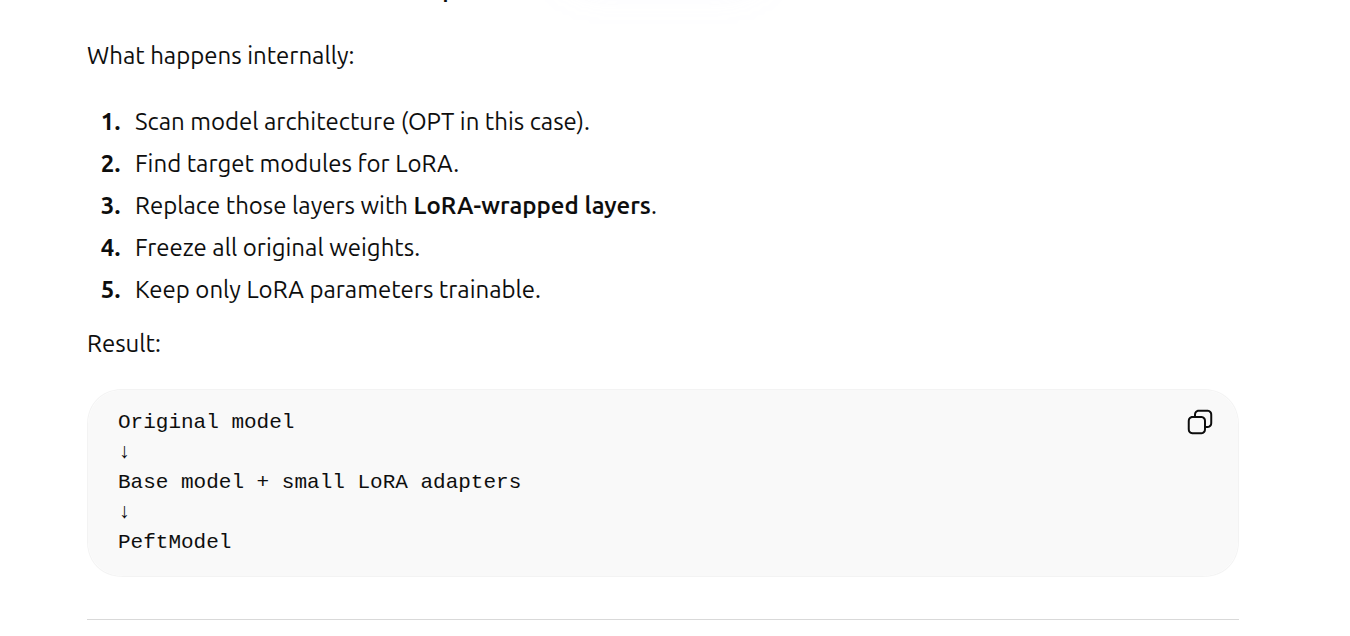

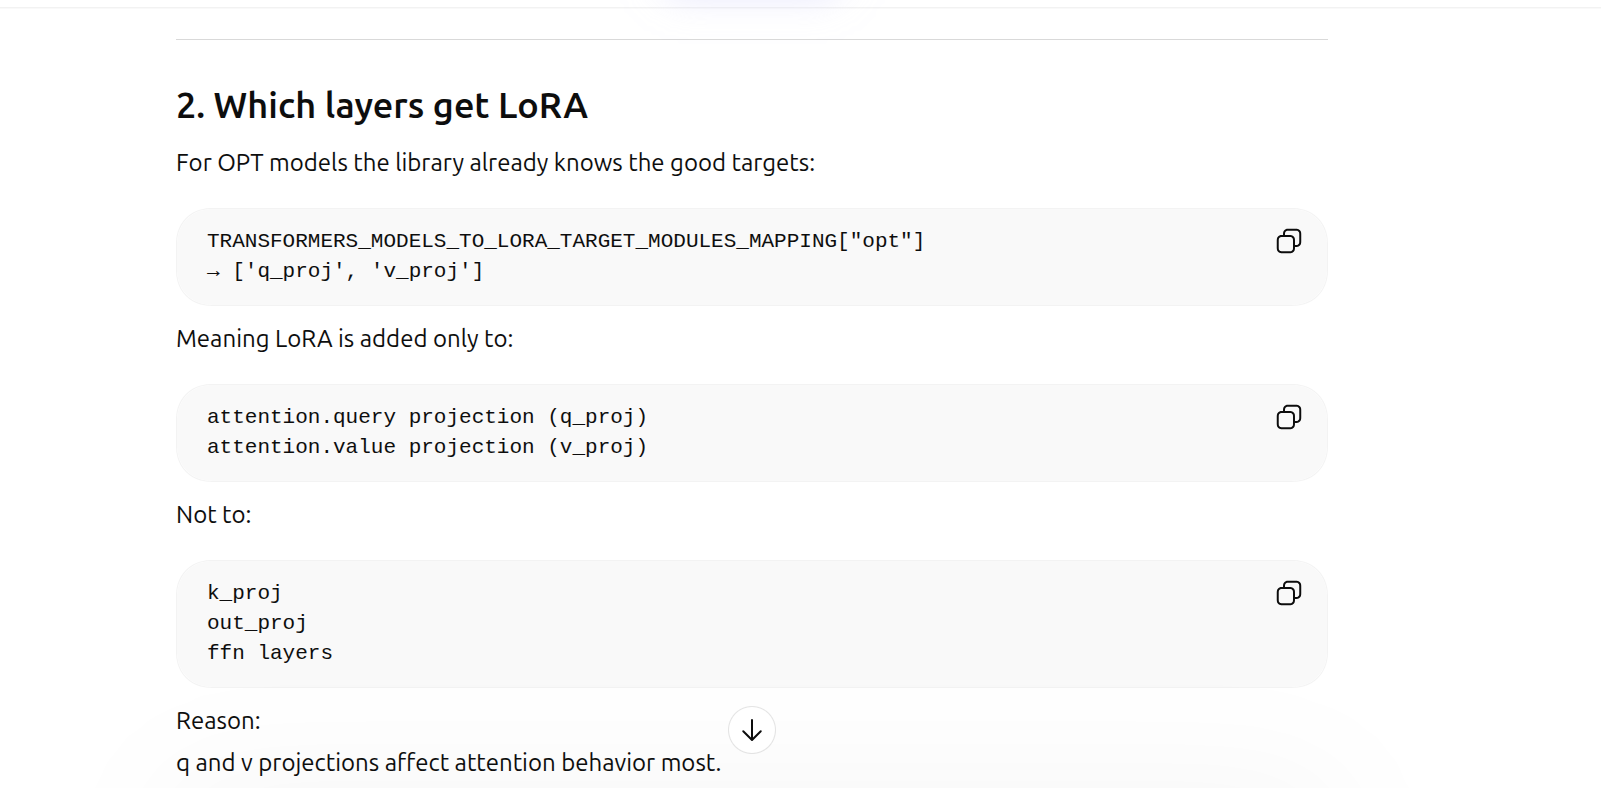

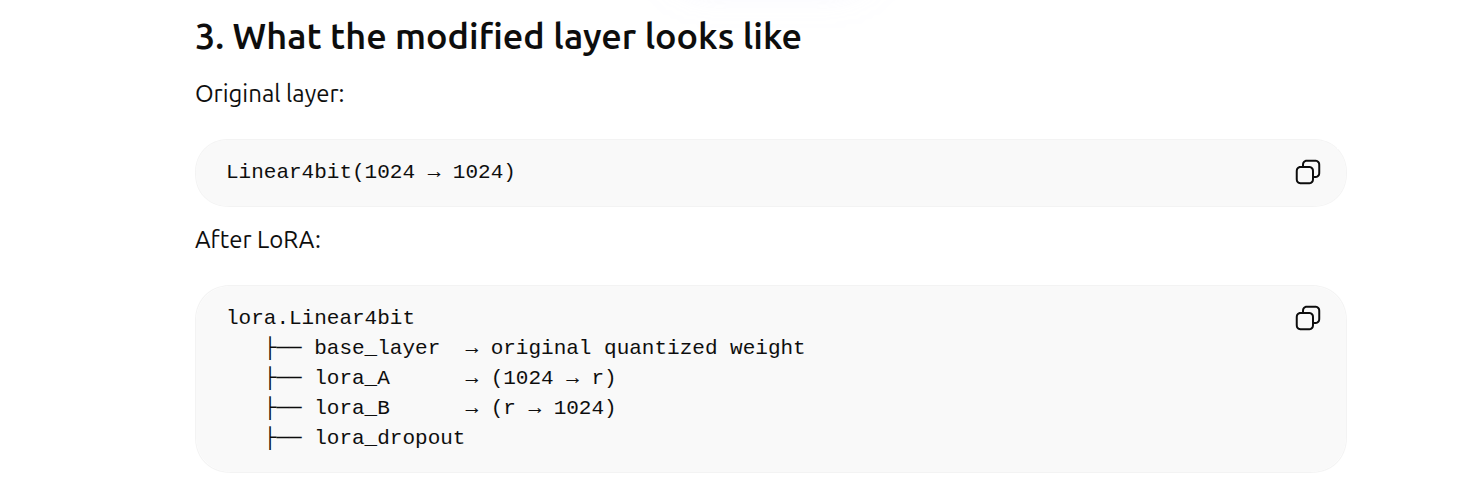

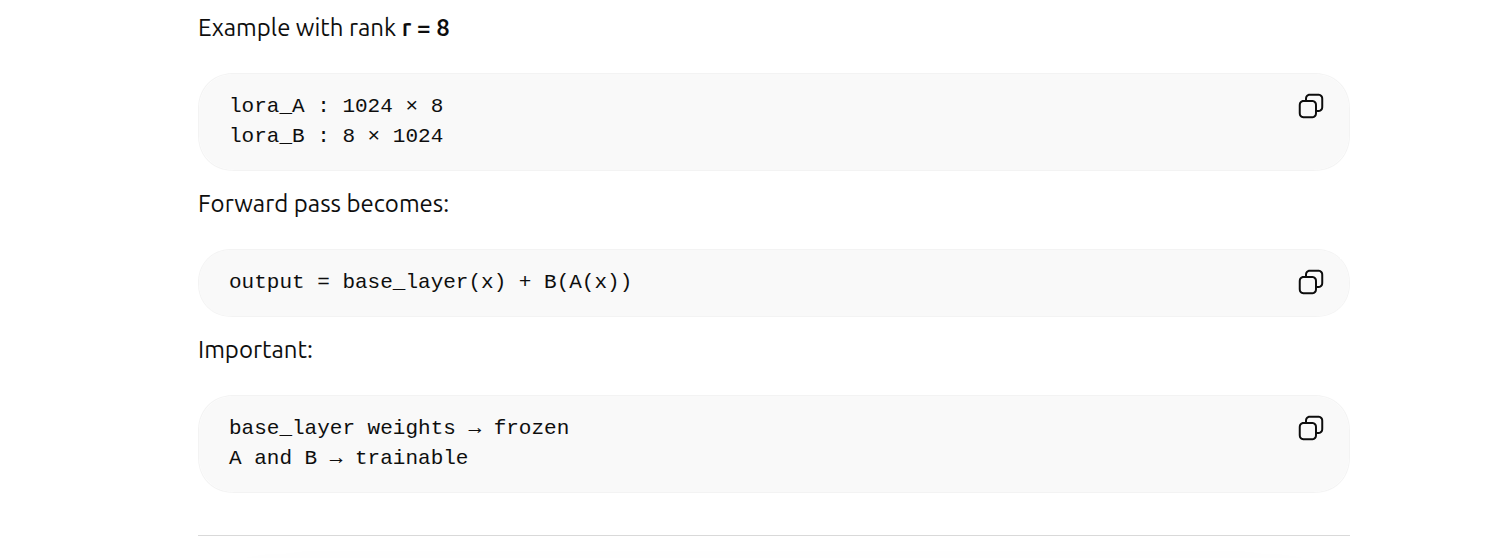

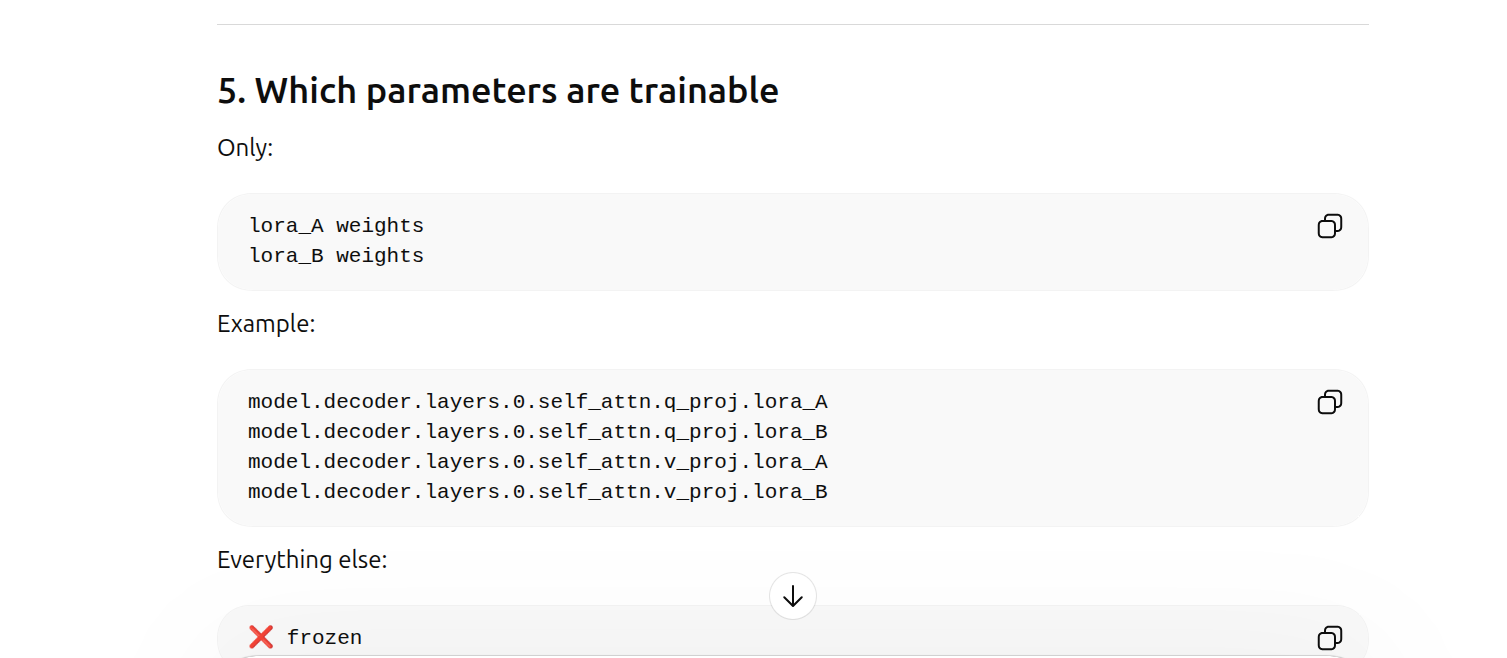

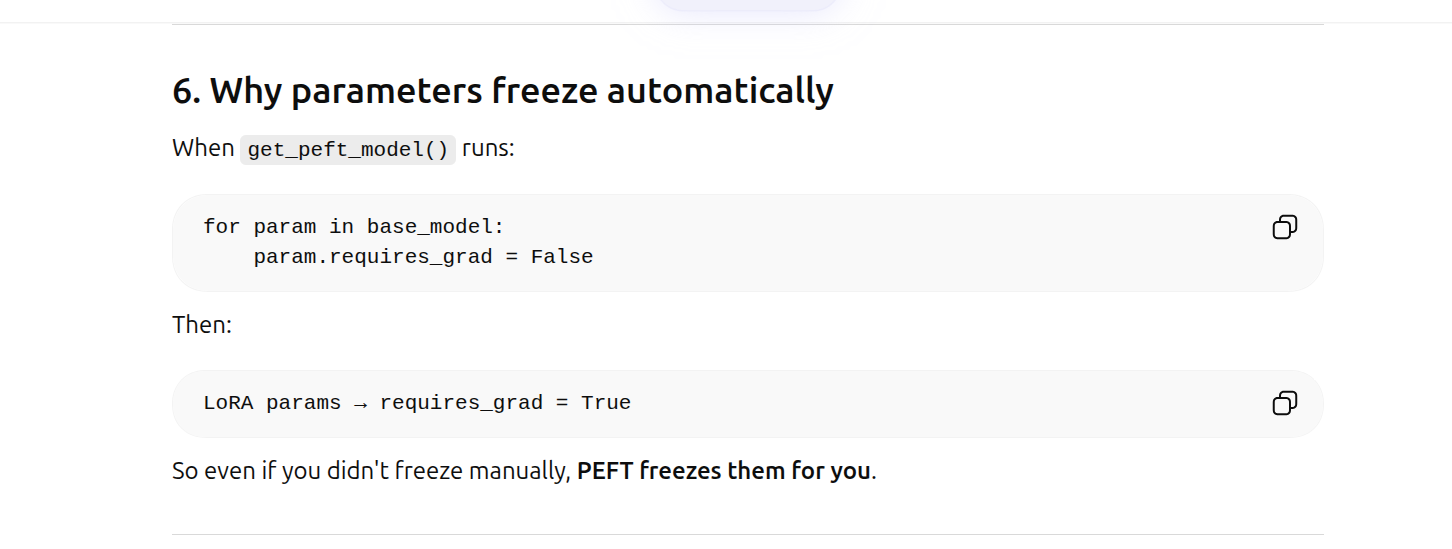

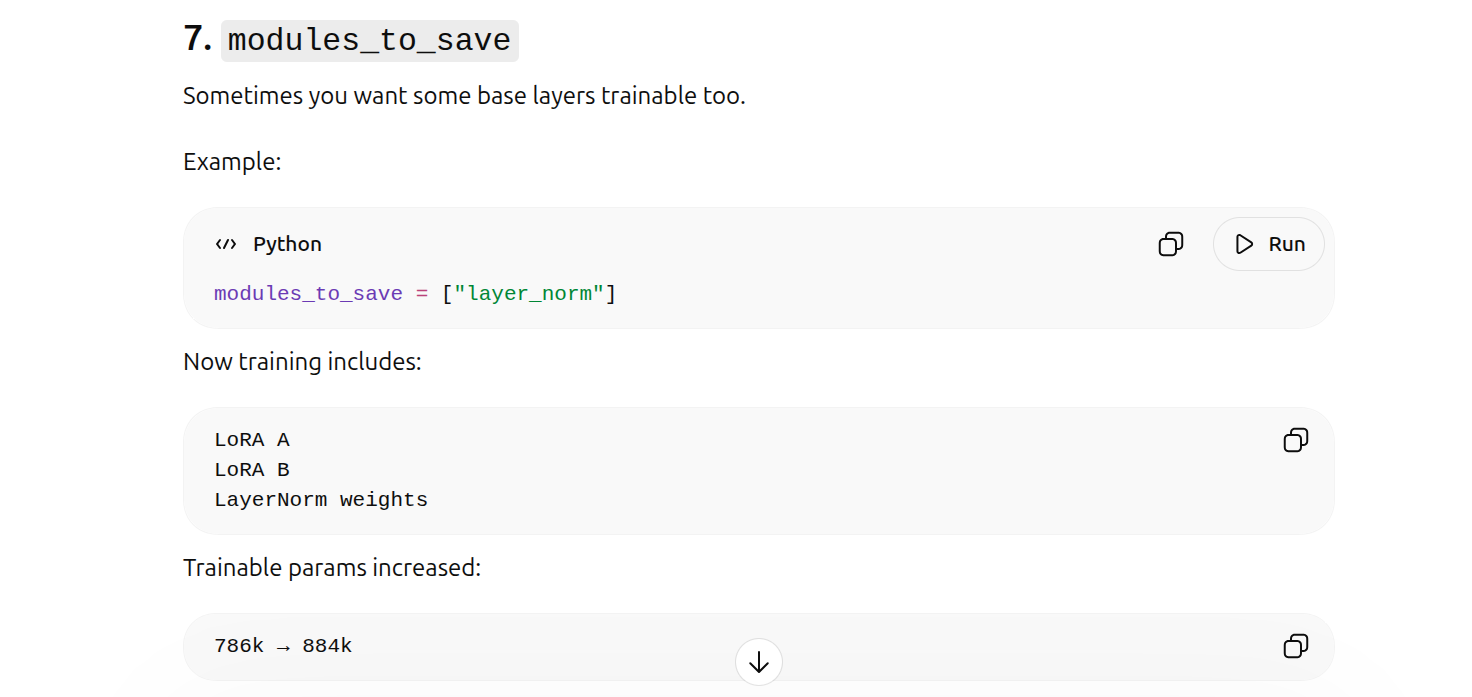

# Embeddings